## **Fine-tuning Aya Vision 8B with Unsloth Per-Language (using Afri-Aya Dataset)**

In this notebook, we do a per-langauge LoRA fine-tuning of Aya Vision 8B (official model: CohereLabs/aya-vision-8b) on our Afri-Aya dataset using unsloth. Follow the instructions and run each cell below.

### Installation

In [16]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth 
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.55.4 
!pip install --no-deps trl==0.22.2
!pip install datasets==4.0.0

In [5]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

0

### Imports

In [7]:
from unsloth import FastVisionModel
import torch
import os
from datasets import load_dataset
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [ ]:
# Login to Hugging Face to access data and models
!hf auth login --token YOUR_HUGGINGFACE_TOKEN_HERE

### Configure, Load Model and Dataset

In [ ]:
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ===== CONFIG =====
LANGUAGE = "Krio" # Set your own language here Exactly as in dataset (e.g., "Kinyarwanda", "Yoruba", etc.)
# Load the Aya Vision model
model, tokenizer = FastVisionModel.from_pretrained(
    "CohereLabs/aya-vision-8b",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)
# Configure LoRA for fine-tuning
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=False,
    finetune_mlp_modules=True,
    r=8,
    lora_alpha=8,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)
print(f"Loading Afri-Aya dataset, filtering for {LANGUAGE}...")

# Load Afri-Aya dataset
full_dataset = load_dataset("CohereLabsCommunity/afri-aya", split="train")

# Filter for the selected language
dataset = full_dataset.filter(lambda x: x["language"] == LANGUAGE)
print(f"Found {len(dataset)} examples for {LANGUAGE}")

# Structure data into supported Aya vision chat template
def data_to_chat(ex):
    """
    Format data into Aya vision chat template.
    Using target language or local Q and A pairs only
    """
    q, a = None, None
    
    # Try to extract first QA pair
    if isinstance(ex.get("qa_pairs"), list) and ex["qa_pairs"]:
        qa0 = ex["qa_pairs"][0] or {}
        q = qa0.get("question_local")
        a = qa0.get("answer_local")
    
    # Fallback to caption if no QA pair found
    if not q or not a:
        q = f"Describe this image in {LANGUAGE}"
        a = ex.get("caption_local", "")
    
    # If still no answer, skip this example
    if not a:
        return None
    
    # System prompt to bias generation to the selected language
    sys_text = (
        f"System instruction: Reply strictly in **{LANGUAGE}**. "
        f"Use the native orthography and natural phrasing. "
        f"Do not translate to English unless explicitly asked."
    )
    
    messages = [
        {"role": "system", "content": [{"type": "text", "text": sys_text}]},
        {"role": "user", "content": [
            {"type": "image"}, 
            {"type": "text", "text": str(q)}
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": str(a)}]},
    ]
    
    return {"messages": messages, "images": [ex["image"]]}

# Apply formatting
print("Formatting dataset...")
formatted_dataset = dataset.map(
    data_to_chat,
    remove_columns=dataset.column_names,
    batched=False,
)

# Remove any None entries from failed conversions
formatted_dataset = formatted_dataset.filter(lambda x: x is not None)

print(f"Formatted {len(formatted_dataset)} examples successfully")

/root/miniconda3/lib/python3.13/site-packages/transformers/models/cohere2/configuration_cohere2.py:235: FutureWarning: The `sliding_window_pattern` attribute is deprecated and will be removed in v4.55.0.
  warnings.warn(


==((====))==  Unsloth 2025.9.11: Fast Aya_Vision patching. Transformers: 4.55.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.394 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:10<00:00,  2.74s/it]


Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients
Loading Afri-Aya dataset, filtering for Krio...
Found 75 examples for Krio
Formatting dataset...
Formatted 75 examples successfully


In [ ]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

### Train Model (to support your langauge only)

In [ ]:
FastVisionModel.for_training(model) # Enable training mode

# Create trainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(
        model, 
        tokenizer, 
        resize=(336, 336)  # Works well with Aya Vision
    ),
    train_dataset=formatted_dataset,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=10,  # for full training
        # max_steps=200,  
        learning_rate=2e-4,
        logging_steps=1,
        optim="paged_adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir=f"outputs_{LANGUAGE}",
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=2048,
    ),
)
print(f"Starting training for {LANGUAGE}...")
trainer_stats = trainer.train()
print("Training complete!")
print(f"Model saved to: outputs_{LANGUAGE}")

# Save the lora model
model.save_pretrained(f"lora_model_{LANGUAGE}")
tokenizer.save_pretrained(f"lora_model_{LANGUAGE}")
print(f"LoRA adapter saved to: lora_model_{LANGUAGE}")

Starting training for Krio...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 75 | Num Epochs = 10 | Total steps = 190
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 16,512,768 of 8,648,354,800 (0.19% trained)


Step,Training Loss
1,5.926000
2,6.049400
3,5.638800
4,5.476100
5,4.648100
6,4.170900
7,3.514800
8,2.829400
9,2.779400
10,2.256200


Training complete!
Model saved to: outputs_Krio
LoRA adapter saved to: lora_model_Krio


In [3]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

0

## Inference Fine-tuned Model
Now we can inference from either of the saved weights: lora in "lora_model_{YOUR_LANGUAGE}" or from checkpoints in "ouputs_{YOUR_LANGUAGE}"

==((====))==  Unsloth 2025.9.11: Fast Aya_Vision patching. Transformers: 4.55.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.394 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:08<00:00,  2.03s/it]


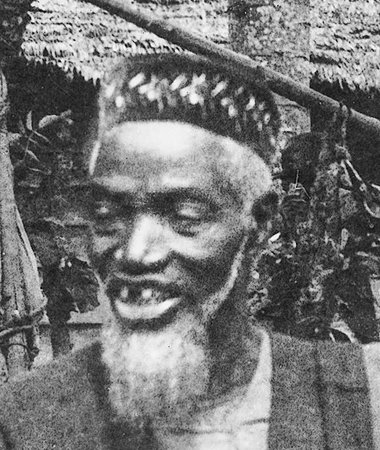

Question: Na wetin di pikchɔ de sho?
Response: Di pikchɔ sho wan man we na wetin blak sken wit wan big, kinky fris, ahn difinishm men. Pipul say na feymus fɔ in Afrika.


In [51]:
# Load your fine-tuned model
model, tokenizer = FastVisionModel.from_pretrained(
    "outputs_Krio/checkpoint-190",  # use either your adapter folder or a specific checkpoint: e.g lora_model_Krio or outputs_Krio/checkpoint-100
    load_in_4bit=True,
)
FastVisionModel.for_inference(model) 

# Get first image from your language 
krio_data = dataset.filter(lambda x: x["language"] == "Krio")
image = krio_data[0]["image"]

# Create prompt
messages = [
    # {"role": "system", "content": [{"type": "text", "text": "Reply strictly in Krio."}]}, # use to boost response in your language
    {"role": "user", "content": [
        {"type": "image"}, 
        {"type": "text", "text": "Na wetin di pikchɔ de sho?"}  # "What does this picture show?" change to your language or even english
    ]}
]

# Apply chat template and generate
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(image, input_text, return_tensors="pt").to("cuda")

# Generate response
outputs = model.generate(
    **inputs, max_new_tokens=100, 
    temperature=1.5, min_p = 0.1,
    # repetition_penalty=1.2, 
    # no_repeat_ngram_size=3, 
    use_cache=True
)
question = messages[0]['content'][1]['text']
# Decode response
response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

image.show()
print("Question:", question)
print("Response:", response)

### Push Model to Hub

In [ ]:
from unsloth import FastVisionModel
model, tokenizer = FastVisionModel.from_pretrained(
    "outputs_Krio/checkpoint-190",  # use either your adapter folder or a specific checkpoint: e.g lora_model_Krio or outputs_Krio/checkpoint-190
    load_in_4bit=True,
)
model.push_to_hub_merged("YOUR_USERNAME/afri-aya-vision-krio-8b", tokenizer, token = "YOUR_HF_TOKEN")